

# Calculating $\pi$ using Monte Carlo Methods
---------------------------------------------

# Background 

`Pi` is in fact what mathematicians call an irrational number, meaning that it is a number that can't be written as a simple fraction, or in other words it has an infinite, non-repeating number of decimal digits. Move over 3.14 - here is the value of `Pi` to 100 digits:
 
```
3.1415926535897932384626433832795028841971693993751058209749445923078164062862089986280348253421170679
```
 
If you think that's too much to retain, in October 2015 Suresh Kumar Sharma of India recited 70,030 digits of `Pi` in just over 17 hours.
 
The fact that `Pi` is infinite hasn't stopped mathematicians trying to calculate it to as many digits as possible.  In November 2016, Peter Trueb used some fairly chunky computing power to calculate it to 22,459,157,718,361 decimal places.

In this exercise, we will approximate `Pi` by throwing darts at a dart board using Monte Carlo simulation [Monte Carlo simulation](https://www.ibm.com/cloud/learn/monte-carlo-simulation). Monte Carlo methods employ statistical algorithms to estimate an unknown quantity. For us, this unknown quantity is . The method starts by inscribing a circle inside of a square.


Write a program to create the square and circle and randomly create points that fall within the square. Count the number of points that fall within the circle. Finally, compute the ratio of the number of points in the circle to the total number of points.

<img src="assets/darts.png" width="50%">

_Figure 1. The circle and the square give us our dartboard and back-board respectively, with the circle fitting perfectly inside the square with a radius of 1._


## Methodology

The definition of a circle is a point, called the center, and all the points that are equal distance from the center. Given the center of the circle, use the distance function to test if a random point is inside the circle; that is, the distance from the point to the circle's center is less than the circle’s radius.

- Area of a square: $s_{area} = (2 r)^2$
- Area of the circle: $c_{area} = \pi r^2$
- $c_{area}/s_{area} = (\pi r^2) / (4 r^2) = \pi / 4$
- $\pi = 4 * c/s$

In [1]:
# Importing modules that we will need
import random
import matplotlib.pyplot as plt

In [38]:
# Initializing the number of samples in Monte Carlo simulation (ie. dart throws)
# adjusted for the table later
num_points = 100000

In [39]:
# Generate random `x,y` coordinates (ie. the dart throws) and count the number of hits
points = []
hits = 0

for _ in range(num_points):
    x = random.uniform(0, 1)
    y = random.uniform(0, 1)
    points.append((x, y))
    
    if x**2 + y**2 <= 1:
        hits += 1

<img src="assets/darts2.png" width="50%">

_Figure 2: Plot your dart throws using matplotlib simular to that shown in the figure._

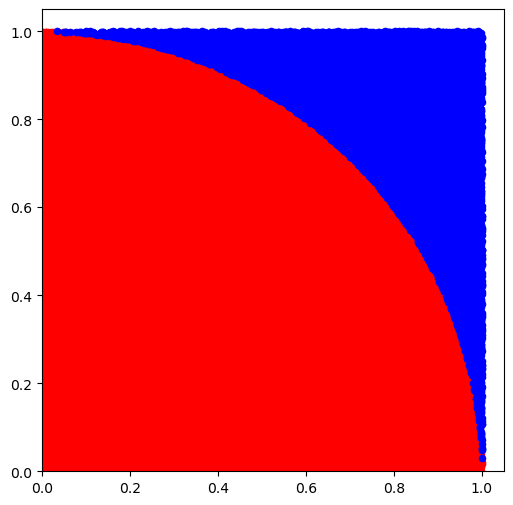

In [ ]:
# Plot the points using matplotlib similar to Figure above

inside_x = []
inside_y = []
outside_x = []
outside_y = []

for x, y in points:
    if x**2 + y**2 <= 1:
        inside_x.append(x)
        inside_y.append(y)
    else:
        outside_x.append(x)
        outside_y.append(y)

plt.figure(figsize=(6,6))
plt.scatter(inside_x, inside_y, color='red', s=20)
plt.scatter(outside_x, outside_y, color='blue', s=20)
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.gca().set_aspect('equal')
plt.show()

# note here we printed a lot of points so it looks like a filled area. 

In [41]:
# Compute pi from your simulation data and print the estimate
pi_estimate = 4 * (hits / num_points)
print("Estimated pi value is", pi_estimate)

Estimated pi value is 3.13744


# Results

Construct a table (using markdown) to benchmark a series of experiments for `n` number of points. Also, include the time, $t$, (in seconds) that the simulation took to complete. Choose point values that help to identify trends with the data - note that I used the sample table.

_Only include the time needed to simulate the points and estimate $\pi$. Do not include the time to plot the data._


| $n$ points | $t$ (seconds) | value of $\pi$ |
|---:|---:|---:|
| 1 | 0.000065 | 4.000000 |
| 10 | 0.000009 | 3.200000 |
| 100 | 0.000056 | 3.080000 |
| 1000 | 0.000565 | 3.180000 |
| 10000 | 0.006079 | 3.158000 |
| 100000 | 0.051181 | 3.140480 |
... | ... | ...

# Analysis

Considering the numeric types used in this calculation, what is the actual accuracy of this calculation?



Here we used floating point numbers, which means we have a 15 to 16 decimal digits of precision. 

We must also notice that the main source of inaccuracy here comes from the randomness of the simulation. The estimates do converge as we increase n, with roughly an error rate proportional to 1/sqrt(n)

Given your implementation, approximate how long it would take to compute $\pi$ to 70,030 digits?

Theoretically, it would take about 10^(140060) random points, since we need 10^(2 * number of required correct digits) points given the error rate proportional to 1/sqrt(n). This would take an unpractical long time for most computers. 